# Multilayer Perceptron

## Learning objective

This notebook builds a small **multilayer perceptron (MLP)** — a neural network
with one hidden layer — from scratch with NumPy. The goal is to see why a hidden
layer lets the network learn a **nonlinear** decision boundary that a single
linear model cannot. You should finish able to:

- explain why stacking a nonlinear activation between two linear layers expands
  what the model can represent,
- implement forward propagation, a `tanh` hidden activation, the binary
  cross-entropy loss, backpropagation, and gradient-descent updates,
- train the network on an XOR-style dataset and read its loss curve, and
- discuss activation functions, hidden units, backpropagation, and overfitting.

## The mathematical idea

The classic example a linear model **cannot** solve is **XOR**: two classes
arranged so that no straight line separates them. A single linear layer
$z = \mathbf{w}^\top \mathbf{x} + b$ can only draw a line, so it fails here.

A one-hidden-layer network composes two linear maps with a nonlinearity in
between. With input $\mathbf{x}$, hidden weights $W_1, \mathbf{b}_1$ and output
weights $W_2, b_2$:

$$
\mathbf{h} = \tanh(W_1 \mathbf{x} + \mathbf{b}_1),
\qquad
\hat{p} = \sigma(W_2 \mathbf{h} + b_2).
$$

The hidden activation $\tanh$ is the key: without it the two linear layers would
collapse into a single linear map. With it, each hidden unit learns its own
linear feature, and the output layer combines them into a curved boundary.

We train by minimizing **binary cross-entropy**

$$
L = -\frac{1}{n} \sum_{i=1}^{n}
\Big[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \Big],
$$

and we compute the gradients with **backpropagation** — the chain rule applied
layer by layer, from the output error back to $W_1$. Using
$\delta_2 = \hat{p} - y$ at the output and the fact that
$\tanh'(u) = 1 - \tanh^2(u)$, the hidden error is
$\delta_1 = (\delta_2 W_2)\,(1 - \mathbf{h}^2)$, and each weight is updated by
gradient descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## A reproducible nonlinear dataset

We build an XOR-style dataset: four clusters placed at the corners of a square.
Points in opposite corners share a label, so the positive class occupies two
diagonal corners and the negative class the other two. No straight line can
separate them, which is exactly what makes this a good test for a hidden layer.

In [2]:
n_per_cluster = 60
spread = 0.25

centers = {
    (0, 0): 0,  # bottom-left  -> class 0
    (1, 1): 0,  # top-right    -> class 0
    (0, 1): 1,  # top-left     -> class 1
    (1, 0): 1,  # bottom-right -> class 1
}

X_parts, y_parts = [], []
for (cx, cy), label in centers.items():
    pts = rng.normal(loc=[cx, cy], scale=spread, size=(n_per_cluster, 2))
    X_parts.append(pts)
    y_parts.append(np.full(n_per_cluster, label))

X = np.vstack(X_parts)
y = np.concatenate(y_parts).astype(float)

perm = rng.permutation(X.shape[0])
X, y = X[perm], y[perm]

print('Feature matrix shape:', X.shape)
print('Label distribution:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Feature matrix shape: (240, 2)
Label distribution: {0: 120, 1: 120}


## The network from scratch

The class implements a single hidden layer with `tanh` activation and a sigmoid
output. Weights are initialized with small random values (a fixed seed keeps the
run reproducible). `fit` runs full-batch gradient descent: a forward pass to get
predictions, then backpropagation to get the gradients, then a parameter update.

In [3]:
class SimpleMLP:
    """One-hidden-layer neural network for binary classification."""

    def __init__(self, n_hidden=8, learning_rate=0.5, n_iterations=3000, seed=0):
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.seed = seed

    @staticmethod
    def _sigmoid(z):
        return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

    @staticmethod
    def _bce_loss(y_true, p_pred):
        eps = 1e-12
        p = np.clip(p_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

    def _forward(self, X):
        z1 = X @ self.W1 + self.b1
        h = np.tanh(z1)
        z2 = h @ self.W2 + self.b2
        p = self._sigmoid(z2).ravel()
        return h, p

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        init_rng = np.random.default_rng(self.seed)
        self.W1 = 0.5 * init_rng.standard_normal((n_features, self.n_hidden))
        self.b1 = np.zeros(self.n_hidden)
        self.W2 = 0.5 * init_rng.standard_normal((self.n_hidden, 1))
        self.b2 = 0.0
        self.loss_history_ = []

        for _ in range(self.n_iterations):
            # Forward pass.
            h, p = self._forward(X)

            # Backpropagation.
            delta2 = (p - y).reshape(-1, 1) / n_samples        # output error
            grad_W2 = h.T @ delta2
            grad_b2 = delta2.sum()

            delta1 = (delta2 @ self.W2.T) * (1 - h ** 2)        # hidden error
            grad_W1 = X.T @ delta1
            grad_b1 = delta1.sum(axis=0)

            # Gradient-descent update.
            self.W2 -= self.learning_rate * grad_W2
            self.b2 -= self.learning_rate * grad_b2
            self.W1 -= self.learning_rate * grad_W1
            self.b1 -= self.learning_rate * grad_b1

            self.loss_history_.append(self._bce_loss(y, p))

        return self

    def predict_proba(self, X):
        _, p = self._forward(np.asarray(X, dtype=float))
        return p

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## Train the network

We train a network with a handful of hidden units and record the loss at each
iteration.

In [4]:
net = SimpleMLP(n_hidden=8, learning_rate=0.5, n_iterations=3000, seed=0)
net.fit(X, y)

print('Hidden units:', net.n_hidden)
print('Final training loss:', round(net.loss_history_[-1], 4))

Hidden units: 8
Final training loss: 0.1185


## Loss history

The binary cross-entropy should fall as the network learns the XOR pattern.
Compared with a linear model, the curve typically lingers near its starting
value for a while before dropping, as the hidden units find useful features.

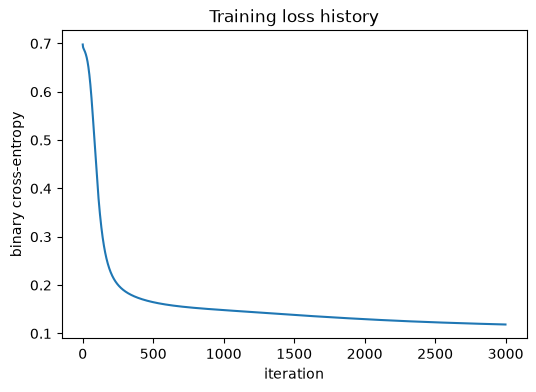

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(net.loss_history_)
ax.set_xlabel('iteration')
ax.set_ylabel('binary cross-entropy')
ax.set_title('Training loss history')
plt.show()

## Learned decision regions

We evaluate the trained network on a dense grid and shade the regions it
assigns to each class, then overlay the data colored by true label. A linear
model could only split this plane with one straight line; the MLP instead
carves out the diagonal XOR structure.

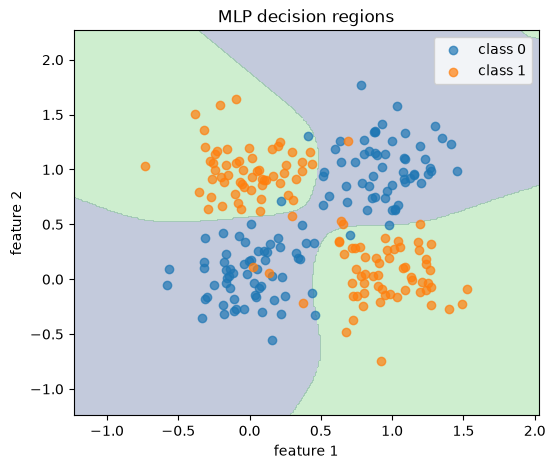

In [6]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = net.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.3, levels=1)
ax.scatter(X[y == 0, 0], X[y == 0, 1], label='class 0', alpha=0.7)
ax.scatter(X[y == 1, 0], X[y == 1, 1], label='class 1', alpha=0.7)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('MLP decision regions')
ax.legend()
plt.show()

## Training accuracy

In [7]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


train_pred = net.predict(X)
print('Training accuracy:', round(accuracy(y, train_pred), 4))

Training accuracy: 0.9583


## Interpretation

The shaded regions follow the XOR layout, and the training accuracy is high —
something a single linear classifier cannot achieve on this data. The hidden
layer is doing the work: each hidden unit contributes a linear feature, and the
output layer combines them into the curved boundary we see.

## Activations, hidden units, backpropagation, and limitations

- **Activation functions.** The nonlinearity between the layers is essential.
  With a linear (or no) activation, the composition of the two layers is still
  just one linear map, and XOR stays unsolvable. We used `tanh`; ReLU and the
  logistic sigmoid are other common choices.
- **Hidden units.** More hidden units give the network more capacity to bend the
  boundary. Too few and it underfits; too many and it can overfit or train more
  slowly. The count is a hyperparameter to tune.
- **Backpropagation.** Training relies on the chain rule to send the output
  error backward and compute each layer's gradient efficiently. It is what makes
  gradient descent practical for multi-layer networks.
- **Overfitting risk and limitations.** A flexible network can memorize noise,
  especially on small datasets, so its training accuracy can overstate true
  performance. Results also depend on the random weight initialization and the
  learning rate. Next steps include a held-out **validation set**, **early
  stopping** or **regularization**, and additional layers or units for harder
  problems.